# EDA — GPS Fleet Analytics

Analisis exploratorio de 18,133 viajes de 66 unidades en 8 agencias (dic 2021 - ene 2022).

**Fuente:** `data_gps/fleet.db` (SQLite generado por el pipeline ETL)

**Constantes de negocio:**
- Rendimiento: 17.23 km/litro
- Precio gasolina: $23.24 MXN/litro
- Semaforo: verde < 3,000 km | amarillo 3,000-6,000 km | rojo > 6,000 km

In [45]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

conn = sqlite3.connect("data_gps/fleet.db")

FE = 17.23 # rendimiento 17.23 km/l
FP = 23.24 # precio de litro de gasolina en MXN/l (magna promedio nacional)

# Style
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A", "#19D3F3", "#FF6692", "#B6E880"]

## 1. Vista general del dataset

In [46]:
pd.read_sql("SELECT * FROM trips LIMIT 5", conn)

,id,unit,agency,date,day,month,year,start_time,end_time,off_hours,distance_km,avg_speed_kmh,max_speed_kmh,travel_time_min,idle_time_min
0,1,UNIT-38,SAN JUAN,2021-12-01,Wednesday,December,2021,06:39,06:50,no,9.70,55.0,82.0,10.0,10.0
1,2,UNIT-38,SAN JUAN,2021-12-01,Wednesday,December,2021,07:00,07:47,no,67.65,88.0,124.0,46.0,971.0
2,3,UNIT-38,SAN JUAN,2021-12-02,Thursday,December,2021,12:17,12:23,no,3.26,33.0,73.0,6.0,8.0
3,4,UNIT-38,SAN JUAN,2021-12-02,Thursday,December,2021,12:31,13:01,no,25.70,51.0,97.0,30.0,0.0
4,5,UNIT-38,SAN JUAN,2021-12-02,Thursday,December,2021,13:02,14:09,no,54.45,49.0,98.0,67.0,0.0


In [47]:
# total de viajes, total de unidades, total de agencias, de que fecha inicia el analisis y fue es la ultima fecha
pd.read_sql("""
    SELECT
        COUNT(*) AS total_trips,
        COUNT(DISTINCT unit) AS units,
        COUNT(DISTINCT agency) AS agencies,
        ROUND(MIN(date)) AS first_date,
        ROUND(MAX(date)) AS last_date
    FROM trips
""", conn)

,total_trips,units,agencies,first_date,last_date
0,18133,66,8,2021.0,2022.0


## 2. Distribucion por agencia

In [48]:
# unidades por agencia, suma de km de todas las unidades/agencia
# suma de litros de unidades/agencia
# costo de gas/agencia
# agrupacion por agencia y orden por costo descendente
pd.read_sql(f"""
    SELECT agency,
        COUNT(DISTINCT unit) AS units, 
        COUNT(*) AS trips,
        ROUND(SUM(distance_km), 0) AS total_km,
        ROUND(SUM(distance_km) / {FE}, 0) AS liters,
        ROUND((SUM(distance_km) / {FE}) * {FP}, 0) AS cost_mxn
    FROM trips
    GROUP BY agency
    ORDER BY cost_mxn DESC
""", conn)

,agency,units,trips,total_km,liters,cost_mxn
0,CELAYA,10,3589,59012.0,3425.0,79596.0
1,SILAO,11,3320,45695.0,2652.0,61634.0
2,SAN JUAN,8,2268,43089.0,2501.0,58118.0
3,QUERETARO,10,2579,42689.0,2478.0,57579.0
4,AGUASCALIENTES,10,2288,41573.0,2413.0,56074.0
5,S.L.P.,7,2345,40750.0,2365.0,54963.0
6,ZACATECAS,4,1206,21295.0,1236.0,28723.0
7,TOLUCA,6,538,7104.0,412.0,9582.0


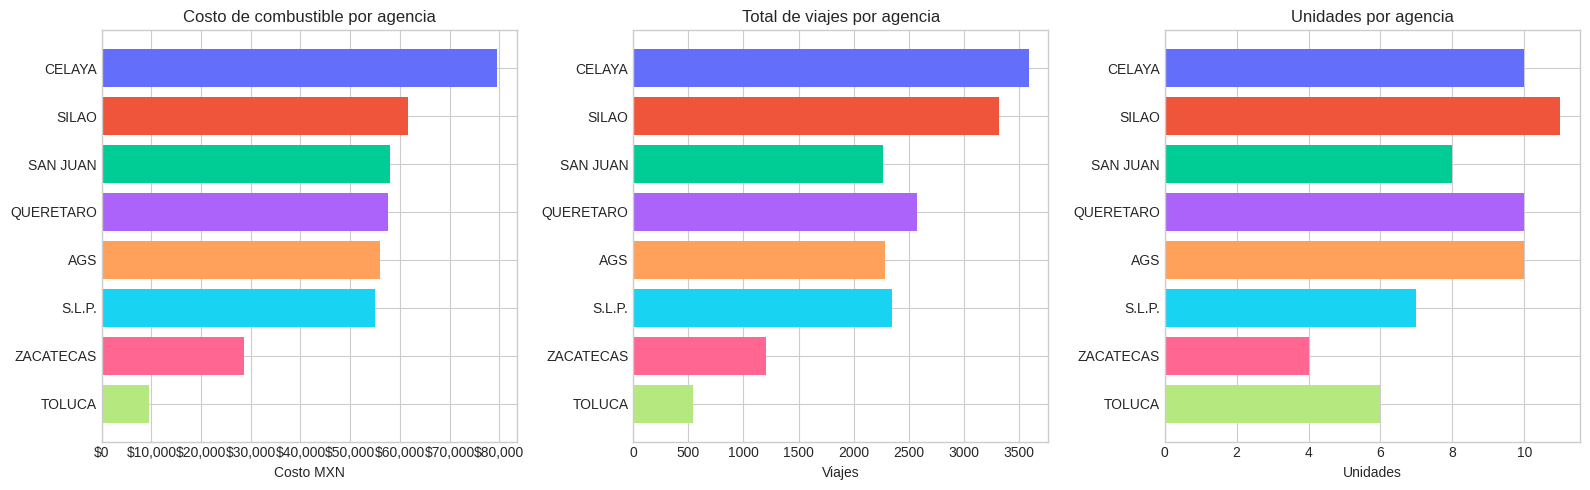

In [49]:
df_agency = pd.read_sql(f"""
    SELECT REPLACE(agency, 'AGUASCALIENTES', 'AGS') AS agency,
        COUNT(DISTINCT unit) AS units,
        COUNT(*) AS trips,
        ROUND(SUM(distance_km), 0) AS total_km,
        ROUND((SUM(distance_km) / {FE}) * {FP}, 0) AS cost_mxn
    FROM trips GROUP BY agency ORDER BY cost_mxn DESC
""", conn)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Costo por agencia
axes[0].barh(df_agency["agency"], df_agency["cost_mxn"], color=COLORS[:len(df_agency)])
axes[0].set_xlabel("Costo MXN")
axes[0].set_title("Costo de combustible por agencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].invert_yaxis()

# Viajes por agencia
axes[1].barh(df_agency["agency"], df_agency["trips"], color=COLORS[:len(df_agency)])
axes[1].set_xlabel("Viajes")
axes[1].set_title("Total de viajes por agencia")
axes[1].invert_yaxis()

# Unidades por agencia
axes[2].barh(df_agency["agency"], df_agency["units"], color=COLORS[:len(df_agency)])
axes[2].set_xlabel("Unidades")
axes[2].set_title("Unidades por agencia")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

Celaya es la agencia con mayor gasto de combustible pero tambien mayor total de viajes 

---


## 3. Semaforo por unidad (top 15 mas costosas)

In [50]:
# suma de km/unidad, suma de costo de combustible/unidad
# status verde si suma de kms menor de 3000 km
# status amarillo si suma dee kms menor o igual 6000 km 
# status rojo si suma de kms mayor de 6000 kms
# agrupacion por unidades y agencia, orden por kms recorridos de unidad
# top 15
pd.read_sql(f"""
    SELECT unit, agency,
        ROUND(SUM(distance_km), 0) AS total_km,
        ROUND((SUM(distance_km) / {FE}) * {FP}, 0) AS cost_mxn,
        CASE
            WHEN SUM(distance_km) < 3000 THEN 'green'
            WHEN SUM(distance_km) <= 6000 THEN 'yellow'
            ELSE 'red'
        END AS status
    FROM trips
    GROUP BY unit, agency
    ORDER BY total_km DESC
    LIMIT 15
""", conn)

,unit,agency,total_km,cost_mxn,status
0,UNIT-14,CELAYA,11102.0,14974.0,red
1,UNIT-34,S.L.P.,10947.0,14765.0,red
2,UNIT-17,CELAYA,10708.0,14443.0,red
3,UNIT-08,AGUASCALIENTES,10640.0,14352.0,red
4,UNIT-39,SAN JUAN,10007.0,13497.0,red
5,UNIT-32,S.L.P.,9779.0,13191.0,red
6,UNIT-11,CELAYA,8409.0,11342.0,red
7,UNIT-21,QUERETARO,8105.0,10932.0,red
8,UNIT-31,S.L.P.,7557.0,10192.0,red
9,UNIT-23,QUERETARO,7304.0,9852.0,red


In [51]:
# sumatoria de costo de las 15 unidades mas costosas y que porcentaje represtan del total
pd.read_sql(f"""
  SELECT                                                                                         
      ROUND(SUM(cost_mxn), 0) AS top15_total,                                                    
      ROUND(SUM(cost_mxn) * 100.0 / (SELECT (SUM(distance_km) / {FE}) * {FP} FROM trips), 1) AS
  pct_del_total
  FROM (
      -- query anidada
      SELECT ROUND((SUM(distance_km) / {FE}) * {FP}, 0) AS cost_mxn
      FROM trips
      GROUP BY unit
      ORDER BY cost_mxn DESC
      LIMIT 15)
""", conn)

,top15_total,pct_del_total
0,171514.0,42.2


### Las 15 unidades top mas costosas representan el 42.2% del costo total de combustible

---

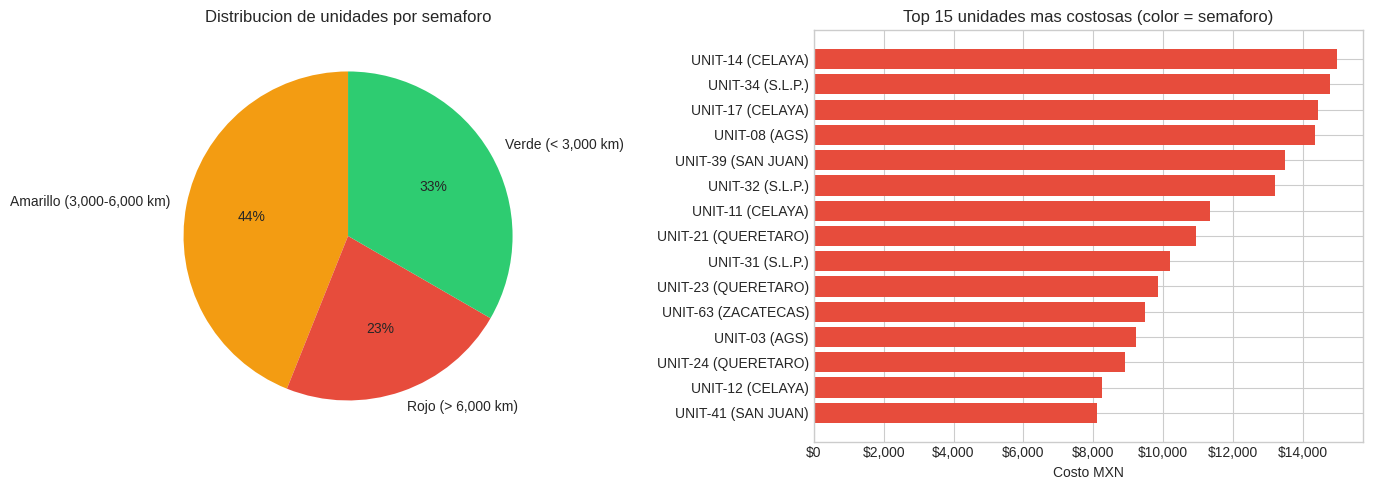

In [52]:
df_status = pd.read_sql(f"""
    SELECT
        CASE
            WHEN SUM(distance_km) < 3000 THEN 'Verde (< 3,000 km)'
            WHEN SUM(distance_km) <= 6000 THEN 'Amarillo (3,000-6,000 km)'
            ELSE 'Rojo (> 6,000 km)'
        END AS status,
        COUNT(*) AS units
    FROM trips
    GROUP BY unit
""", conn).groupby("status")["units"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart de distribucion de semaforo
status_colors = {"Verde (< 3,000 km)": "#2ecc71", "Amarillo (3,000-6,000 km)": "#f39c12", "Rojo (> 6,000 km)": "#e74c3c"}
axes[0].pie(df_status.values, labels=df_status.index, autopct="%1.0f%%",
    colors=[status_colors.get(s, "#999") for s in df_status.index], startangle=90)
axes[0].set_title("Distribucion de unidades por semaforo")

# Top 15 unidades mas costosas
df_top = pd.read_sql(f"""
    SELECT unit || ' (' || REPLACE(agency, 'AGUASCALIENTES', 'AGS') || ')' AS label,
        ROUND((SUM(distance_km) / {FE}) * {FP}, 0) AS cost_mxn,
        CASE
            WHEN SUM(distance_km) < 3000 THEN '#2ecc71'
            WHEN SUM(distance_km) <= 6000 THEN '#f39c12'
            ELSE '#e74c3c'
        END AS color
    FROM trips GROUP BY unit, agency ORDER BY cost_mxn DESC LIMIT 15
""", conn)
axes[1].barh(df_top["label"], df_top["cost_mxn"], color=df_top["color"])
axes[1].set_xlabel("Costo MXN")
axes[1].set_title("Top 15 unidades mas costosas (color = semaforo)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Viajes fuera de horario por agencia

In [53]:
pd.read_sql(f"""
    SELECT agency,
        COUNT(*) AS total_trips,
        SUM(CASE WHEN off_hours = 'yes' THEN 1 ELSE 0 END) AS off_hours_trips,
        ROUND(SUM(CASE WHEN off_hours = 'yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pct_off_hours,
        ROUND(SUM(CASE WHEN off_hours = 'yes' THEN distance_km ELSE 0 END) / {FE} * {FP}, 0) AS off_hours_cost
    FROM trips
    GROUP BY agency
    ORDER BY pct_off_hours DESC
""", conn)

,agency,total_trips,off_hours_trips,pct_off_hours,off_hours_cost
0,SILAO,3320,447,13.5,3563.0
1,TOLUCA,538,69,12.8,747.0
2,QUERETARO,2579,305,11.8,5271.0
3,ZACATECAS,1206,141,11.7,3572.0
4,AGUASCALIENTES,2288,211,9.2,4583.0
5,CELAYA,3589,293,8.2,4570.0
6,S.L.P.,2345,182,7.8,4286.0
7,SAN JUAN,2268,135,6.0,3826.0


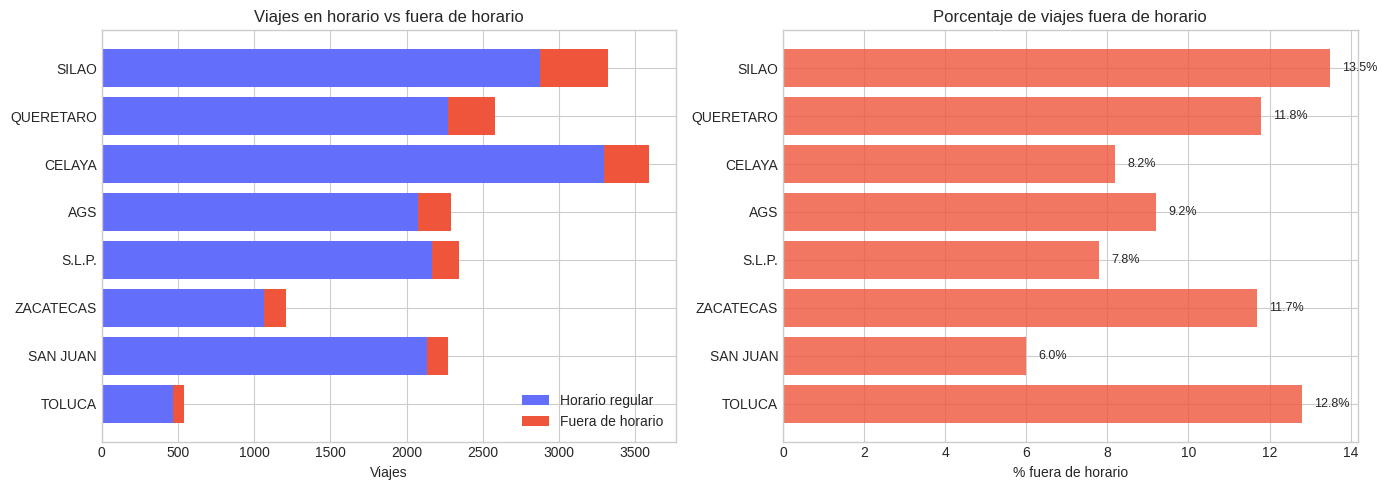

In [54]:
df_off = pd.read_sql(f"""
    SELECT REPLACE(agency, 'AGUASCALIENTES', 'AGS') AS agency,
        SUM(CASE WHEN off_hours = 'yes' THEN 1 ELSE 0 END) AS off,
        SUM(CASE WHEN off_hours = 'no' THEN 1 ELSE 0 END) AS regular
    FROM trips GROUP BY agency ORDER BY off DESC
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: off-hours vs regular
axes[0].barh(df_off["agency"], df_off["regular"], label="Horario regular", color="#636EFA")
axes[0].barh(df_off["agency"], df_off["off"], left=df_off["regular"], label="Fuera de horario", color="#EF553B")
axes[0].set_xlabel("Viajes")
axes[0].set_title("Viajes en horario vs fuera de horario")
axes[0].legend()
axes[0].invert_yaxis()

# % fuera de horario
pct = (df_off["off"] / (df_off["off"] + df_off["regular"]) * 100).round(1)
bars = axes[1].barh(df_off["agency"], pct, color="#EF553B", alpha=0.8)
axes[1].set_xlabel("% fuera de horario")
axes[1].set_title("Porcentaje de viajes fuera de horario")
axes[1].invert_yaxis()
for bar, p in zip(bars, pct):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f"{p}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

#### Agencia Silao, Queretaro y Celaya con mas desplazamientos fuera de horario laboral

## 5. Comparativo dic 2021 vs ene 2022

In [55]:
pd.read_sql(f"""
    SELECT month, year,
        COUNT(*) AS trips,
        COUNT(DISTINCT unit) AS units,
        ROUND(SUM(distance_km), 0) AS total_km,
        ROUND((SUM(distance_km) / {FE}) * {FP}, 0) AS cost_mxn,
        ROUND(AVG(distance_km), 1) AS avg_km_per_trip
    FROM trips
    GROUP BY month, year
    ORDER BY year, month DESC
""", conn)

,month,year,trips,units,total_km,cost_mxn,avg_km_per_trip
0,December,2021,9694,60,157512.0,212453.0,16.2
1,January,2022,8439,62,143694.0,193816.0,17.0


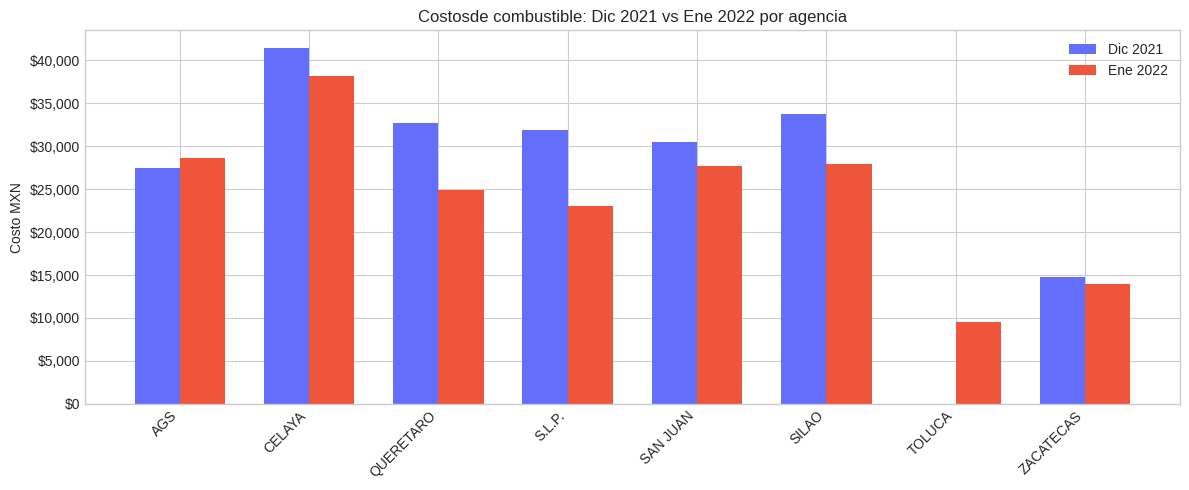

In [56]:
df_month_agency = pd.read_sql(f"""
    SELECT REPLACE(agency, 'AGUASCALIENTES', 'AGS') AS agency, month,
        ROUND((SUM(distance_km) / {FE}) * {FP}, 0) AS cost_mxn
    FROM trips GROUP BY agency, month ORDER BY agency
""", conn)

fig, ax = plt.subplots(figsize=(12, 5))
import numpy as np

agencies = df_month_agency["agency"].unique()
x = np.arange(len(agencies))
width = 0.35

dic = df_month_agency[df_month_agency["month"] == "December"].set_index("agency")["cost_mxn"]
ene = df_month_agency[df_month_agency["month"] == "January"].set_index("agency")["cost_mxn"]

bars1 = ax.bar(x - width/2, [dic.get(a, 0) for a in agencies], width, label="Dic 2021", color="#636EFA")
bars2 = ax.bar(x + width/2, [ene.get(a, 0) for a in agencies], width, label="Ene 2022", color="#EF553B")

ax.set_xticks(x)
ax.set_xticklabels(agencies, rotation=45, ha="right")
ax.set_ylabel("Costo MXN")
ax.set_title("Costosde combustible: Dic 2021 vs Ene 2022 por agencia")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()

plt.tight_layout()
plt.show()

## 6. Patrones por dia de la semana

In [57]:
pd.read_sql("""
    SELECT day,
        COUNT(*) AS trips,
        ROUND(SUM(distance_km), 0) AS total_km,
        ROUND(AVG(distance_km), 1) AS avg_km_per_trip,
        ROUND(AVG(idle_time_min), 0) AS avg_idle_min
    FROM trips
    GROUP BY day
    ORDER BY trips DESC
""", conn)

,day,trips,total_km,avg_km_per_trip,avg_idle_min
0,Wednesday,3347,53495.0,16.0,102.0
1,Thursday,3279,57645.0,17.6,106.0
2,Friday,3250,52778.0,16.2,103.0
3,Monday,3037,46351.0,15.3,106.0
4,Tuesday,2827,50704.0,17.9,104.0
5,Saturday,1852,30412.0,16.4,131.0
6,Sunday,541,9821.0,18.2,161.0


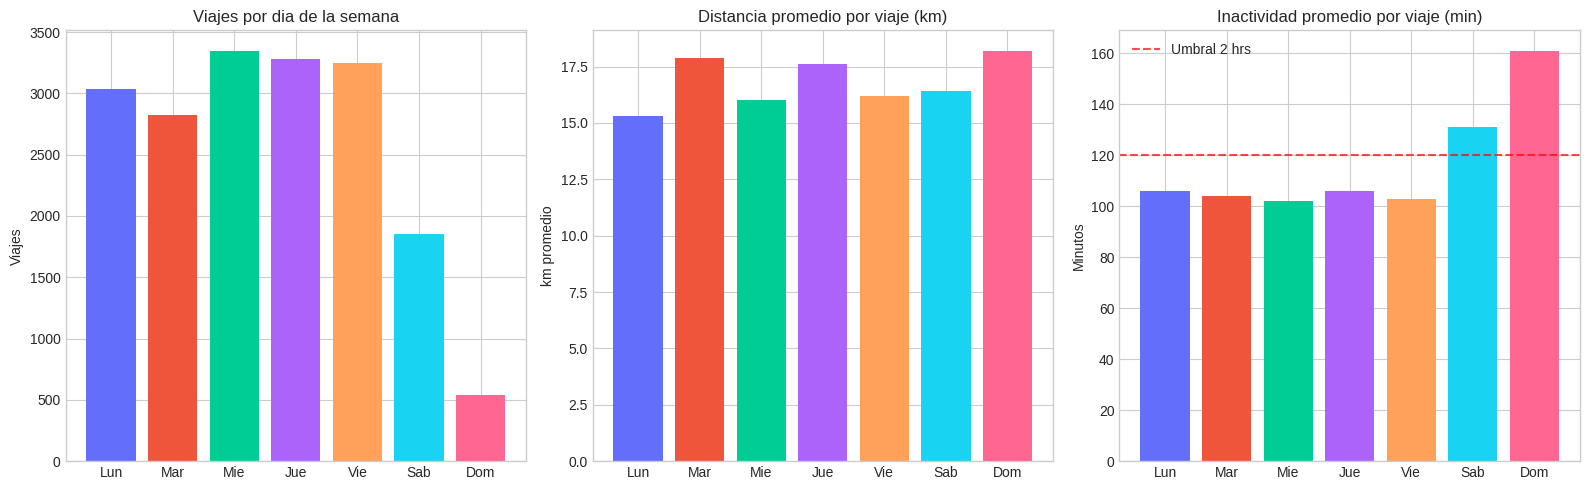

In [58]:
df_day = pd.read_sql("""
    SELECT day, COUNT(*) AS trips,
        ROUND(AVG(distance_km), 1) AS avg_km,
        ROUND(AVG(idle_time_min), 0) AS avg_idle_min
    FROM trips GROUP BY day
""", conn)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_labels = ["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"]
df_day["day"] = pd.Categorical(df_day["day"], categories=day_order, ordered=True)
df_day = df_day.sort_values("day")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Viajes por dia
axes[0].bar(day_labels, df_day["trips"].values, color=COLORS[:7])
axes[0].set_title("Viajes por dia de la semana")
axes[0].set_ylabel("Viajes")

# Distancia promedio por dia
axes[1].bar(day_labels, df_day["avg_km"].values, color=COLORS[:7])
axes[1].set_title("Distancia promedio por viaje (km)")
axes[1].set_ylabel("km promedio")

# Inactividad promedio por dia
bars = axes[2].bar(day_labels, df_day["avg_idle_min"].values, color=COLORS[:7])
axes[2].set_title("Inactividad promedio por viaje (min)")
axes[2].set_ylabel("Minutos")
axes[2].axhline(y=120, color="red", linestyle="--", alpha=0.7, label="Umbral 2 hrs")
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Unidades con mayor inactividad promedio (> 2 hrs)

In [59]:
pd.read_sql("""
    SELECT unit, agency,
        COUNT(*) AS trips,
        ROUND(AVG(idle_time_min), 0) AS avg_idle_min,
        ROUND(SUM(idle_time_min) / 60, 0) AS total_idle_hrs
    FROM trips
    GROUP BY unit, agency
    HAVING AVG(idle_time_min) > 120
    ORDER BY avg_idle_min DESC
    LIMIT 15
""", conn)

,unit,agency,trips,avg_idle_min,total_idle_hrs
0,UNIT-61,TOLUCA,4,455.0,30.0
1,UNIT-62,TOLUCA,9,408.0,61.0
2,UNIT-07,AGUASCALIENTES,40,359.0,239.0
3,UNIT-40,SAN JUAN,196,214.0,699.0
4,UNIT-02,AGUASCALIENTES,207,212.0,731.0
5,UNIT-13,CELAYA,165,209.0,574.0
6,UNIT-26,QUERETARO,129,207.0,446.0
7,UNIT-27,QUERETARO,251,193.0,809.0
8,UNIT-09,AGUASCALIENTES,105,192.0,336.0
9,UNIT-01,AGUASCALIENTES,212,181.0,640.0


## 8. Distribucion de velocidad maxima

In [60]:
pd.read_sql("""
    SELECT
        SUM(CASE WHEN max_speed_kmh < 80 THEN 1 ELSE 0 END) AS 'bajo_80',
        SUM(CASE WHEN max_speed_kmh BETWEEN 80 AND 120 THEN 1 ELSE 0 END) AS '80_a_120',
        SUM(CASE WHEN max_speed_kmh > 120 THEN 1 ELSE 0 END) AS 'sobre_120',
        ROUND(AVG(max_speed_kmh), 0) AS avg_max_speed,
        MAX(max_speed_kmh) AS max_speed_record
    FROM trips
""", conn)

,bajo_80,80_a_120,sobre_120,avg_max_speed,max_speed_record
0,8472,7173,2488,83.0,180.0


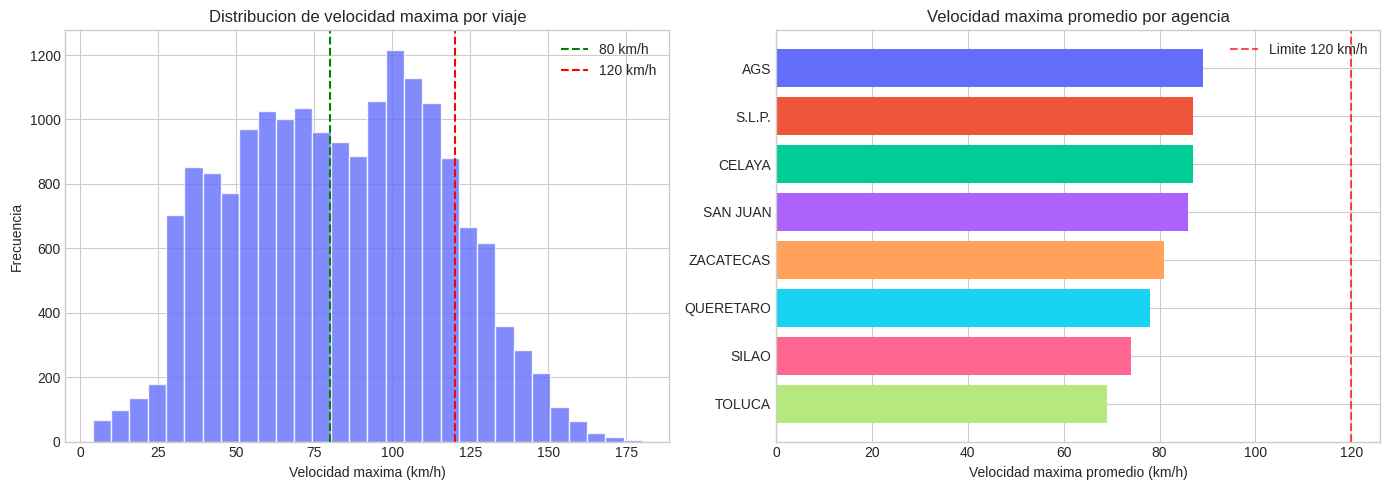

In [61]:
df_speed = pd.read_sql("SELECT max_speed_kmh FROM trips WHERE max_speed_kmh > 0", conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de velocidad maxima
axes[0].hist(df_speed["max_speed_kmh"], bins=30, color="#636EFA", edgecolor="white", alpha=0.8)
axes[0].axvline(x=80, color="green", linestyle="--", label="80 km/h")
axes[0].axvline(x=120, color="red", linestyle="--", label="120 km/h")
axes[0].set_xlabel("Velocidad maxima (km/h)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribucion de velocidad maxima por viaje")
axes[0].legend()

# Velocidad maxima por agencia (boxplot-style con barras)
df_speed_agency = pd.read_sql("""
    SELECT REPLACE(agency, 'AGUASCALIENTES', 'AGS') AS agency,
        ROUND(AVG(max_speed_kmh), 0) AS avg_max,
        MAX(max_speed_kmh) AS record,
        ROUND(AVG(CASE WHEN max_speed_kmh > 120 THEN 1.0 ELSE 0.0 END) * 100, 1) AS pct_over_120
    FROM trips GROUP BY agency ORDER BY avg_max DESC
""", conn)
axes[1].barh(df_speed_agency["agency"], df_speed_agency["avg_max"], color=COLORS[:8])
axes[1].axvline(x=120, color="red", linestyle="--", alpha=0.7, label="Limite 120 km/h")
axes[1].set_xlabel("Velocidad maxima promedio (km/h)")
axes[1].set_title("Velocidad maxima promedio por agencia")
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Resumen de KPIs globales

In [62]:
pd.read_sql(f"""
    SELECT
        COUNT(*) AS total_trips,
        COUNT(DISTINCT unit) AS total_units,
        ROUND(SUM(distance_km), 0) AS total_km,
        ROUND(SUM(distance_km) / {FE}, 0) AS total_liters,
        ROUND((SUM(distance_km) / {FE}) * {FP}, 0) AS total_cost_mxn,
        ROUND(SUM(CASE WHEN off_hours = 'yes' THEN distance_km ELSE 0 END) / {FE} * {FP}, 0) AS off_hours_cost,
        ROUND(SUM(idle_time_min) / 60, 0) AS total_idle_hrs
    FROM trips
""", conn)

,total_trips,total_units,total_km,total_liters,total_cost_mxn,off_hours_cost,total_idle_hrs
0,18133,66,301206.0,17481.0,406270.0,30420.0,32831.0


## 10. Distribucion de distancia por viaje

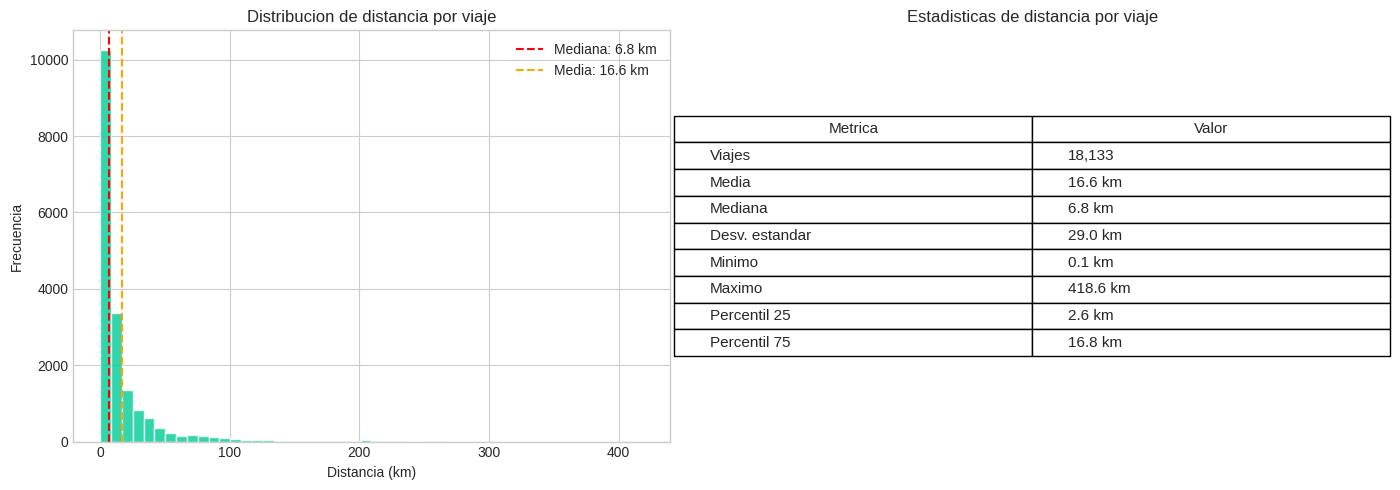

In [ ]:
# df_dist = pd.read_sql("SELECT distance_km FROM trips WHERE distance_km > 0", conn)

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Histograma de distancia
# axes[0].hist(df_dist["distance_km"], bins=50, color="#00CC96", edgecolor="white", alpha=0.8)
# axes[0].set_xlabel("Distancia (km)")
# axes[0].set_ylabel("Frecuencia")
# axes[0].set_title("Distribucion de distancia por viaje")
# axes[0].axvline(x=df_dist["distance_km"].median(), color="red", linestyle="--", label=f"Mediana: {df_dist['distance_km'].median():.1f} km")
# axes[0].axvline(x=df_dist["distance_km"].mean(), color="orange", linestyle="--", label=f"Media: {df_dist['distance_km'].mean():.1f} km")
# axes[0].legend()

# # Estadisticas descriptivas
# stats = df_dist["distance_km"].describe()
# axes[1].axis("off")
# axes[1].set_title("Estadisticas de distancia por viaje")
# table_data = [
#     ["Viajes", f"{stats['count']:,.0f}"],
#     ["Media", f"{stats['mean']:.1f} km"],
#     ["Mediana", f"{stats['50%']:.1f} km"],
#     ["Desv. estandar", f"{stats['std']:.1f} km"],
#     ["Minimo", f"{stats['min']:.1f} km"],
#     ["Maximo", f"{stats['max']:.1f} km"],
#     ["Percentil 25", f"{stats['25%']:.1f} km"],
#     ["Percentil 75", f"{stats['75%']:.1f} km"],
# ]
# table = axes[1].table(cellText=table_data, colLabels=["Metrica", "Valor"], loc="center", cellLoc="left")
# table.auto_set_font_size(False)
# table.set_fontsize(11)
# table.scale(1.2, 1.5)

# plt.tight_layout()
# plt.show()

## 11. Tendencia diaria de costo

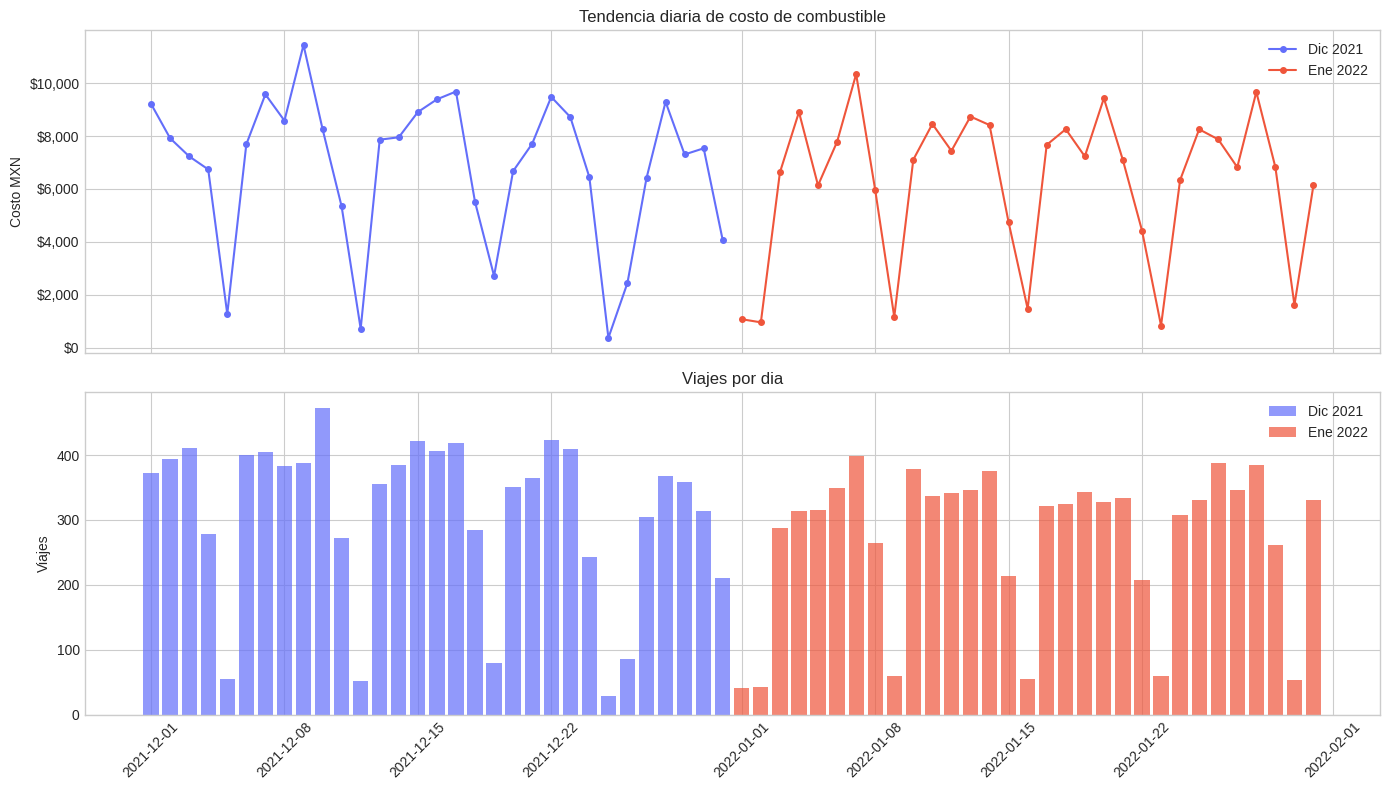

In [40]:
df_trend = pd.read_sql(f"""
    SELECT date, month,
        ROUND((SUM(distance_km) / {FE}) * {FP}, 0) AS cost_mxn,
        COUNT(*) AS trips
    FROM trips GROUP BY date ORDER BY date
""", conn)
df_trend["date"] = pd.to_datetime(df_trend["date"])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Costo diario
for month, color, label in [("December", "#636EFA", "Dic 2021"), ("January", "#EF553B", "Ene 2022")]:
    mask = df_trend["month"] == month
    axes[0].plot(df_trend.loc[mask, "date"], df_trend.loc[mask, "cost_mxn"], marker="o", markersize=4, color=color, label=label)
axes[0].set_ylabel("Costo MXN")
axes[0].set_title("Tendencia diaria de costo de combustible")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend()

# Viajes diarios
for month, color, label in [("December", "#636EFA", "Dic 2021"), ("January", "#EF553B", "Ene 2022")]:
    mask = df_trend["month"] == month
    axes[1].bar(df_trend.loc[mask, "date"], df_trend.loc[mask, "trips"], color=color, alpha=0.7, label=label, width=0.8)
axes[1].set_ylabel("Viajes")
axes[1].set_title("Viajes por dia")
axes[1].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Heatmap: inactividad por agencia y dia

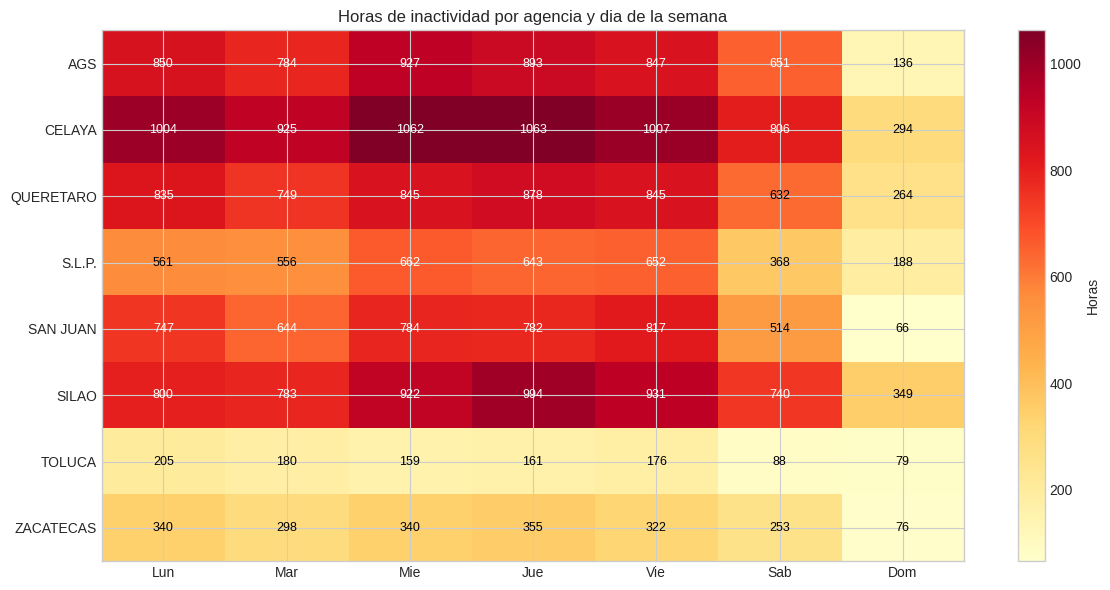

In [65]:
df_heat = pd.read_sql("""
    SELECT REPLACE(agency, 'AGUASCALIENTES', 'AGS') AS agency, day,
        ROUND(SUM(idle_time_min) / 60, 0) AS hours
    FROM trips GROUP BY agency, day
""", conn)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_labels = ["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"]

pivot = df_heat.pivot(index="agency", columns="day", values="hours")
pivot = pivot.reindex(columns=day_order)
pivot.columns = day_labels

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(day_labels)))
ax.set_xticklabels(day_labels)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

# Annotate cells
for i in range(len(pivot.index)):
    for j in range(len(day_labels)):
        val = pivot.values[i, j]
        if not pd.isna(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=9,
                color="white" if val > pivot.values.max() * 0.6 else "black")

ax.set_title("Horas de inactividad por agencia y dia de la semana")
plt.colorbar(im, label="Horas")
plt.tight_layout()
plt.show()

## 13. Distribucion de viajes por hora de inicio

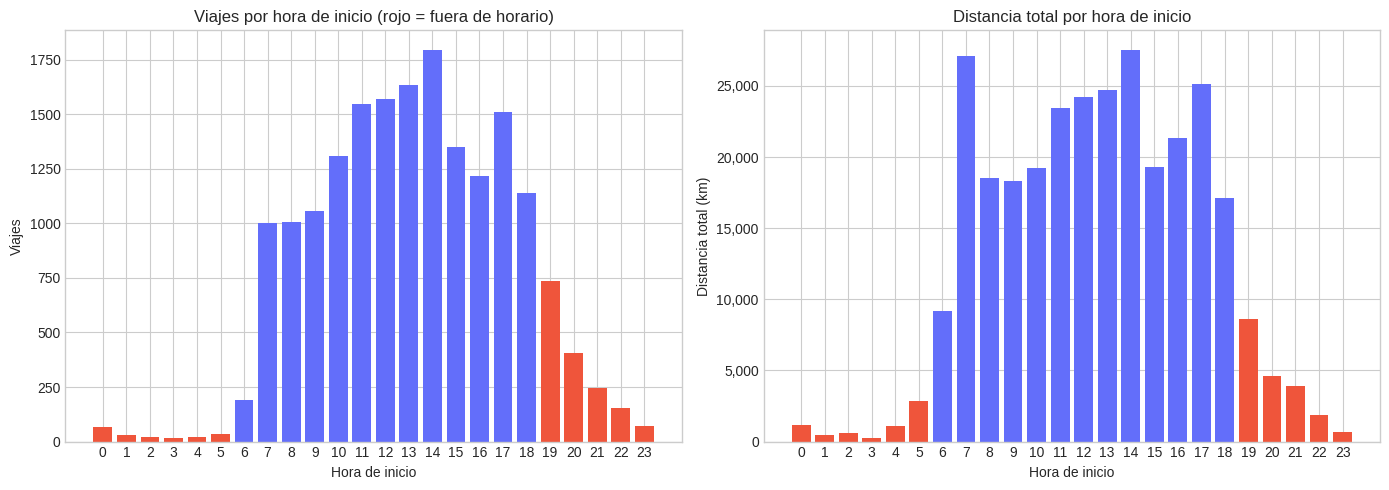

In [ ]:
# df_hour = pd.read_sql("""
#     SELECT CAST(SUBSTR(start_time, 1, 2) AS INTEGER) AS hour,
#         COUNT(*) AS trips,
#         ROUND(SUM(distance_km), 0) AS total_km
#     FROM trips
#     WHERE start_time IS NOT NULL AND LENGTH(start_time) >= 5
#     GROUP BY hour ORDER BY hour
# """, conn)

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Viajes por hora
# colors_hour = ["#EF553B" if (h >= 19 or h <= 5) else "#636EFA" for h in df_hour["hour"]]
# axes[0].bar(df_hour["hour"], df_hour["trips"], color=colors_hour)
# axes[0].set_xlabel("Hora de inicio")
# axes[0].set_ylabel("Viajes")
# axes[0].set_title("Viajes por hora de inicio (rojo = fuera de horario)")
# axes[0].set_xticks(range(0, 24))

# # Distancia por hora
# axes[1].bar(df_hour["hour"], df_hour["total_km"], color=colors_hour)
# axes[1].set_xlabel("Hora de inicio")
# axes[1].set_ylabel("Distancia total (km)")
# axes[1].set_title("Distancia total por hora de inicio")
# axes[1].set_xticks(range(0, 24))
# axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# plt.tight_layout()
# plt.show()

In [43]:
conn.close()